### Linear Regression Analysis

In [1]:
from pathlib import Path
import sys

import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import pearsonr, spearmanr


# Find the repository root from wherever the notebook is launched.
cwd = Path.cwd().resolve()

for folder in [cwd, *cwd.parents]:
    if (folder / "pyproject.toml").exists():
        ROOT = folder
        break
else:
    raise FileNotFoundError("Could not find the repository root.")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from helpers.paths import (
    PROCESSED,
    orestar_transactions_path,
    spending_processed_dir,
)

YEAR_2024 = 2024
YEAR_2026 = 2026
CONTEST = "city_council"

print("ROOT:", ROOT)


# Function to perform linear regression
def OLSlinearRegression(x_data, y_data, x_min, x_max, y_min, y_max, title, saveName = "", colors=[]):

    # Convert to numpy arrays
    x = np.asarray(x_data, dtype=np.float64)
    y = np.asarray(y_data, dtype=np.float64)

    # Fit regression model
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()

    # Create a bunch of x values to use as points for your line of best fit
    x_plot = np.linspace(x_min, x_max, 300)
    X_plot = sm.add_constant(x_plot)

    # Predictions + confidence interval
    pred = model.get_prediction(X_plot)
    pred_summary = pred.summary_frame(alpha=0.05)

    y_pred = pred_summary['mean'].to_numpy(dtype=float)
    ci_lower = pred_summary['mean_ci_lower'].to_numpy(dtype=float)
    ci_upper = pred_summary['mean_ci_upper'].to_numpy(dtype=float)

    # R^2
    r_squared = model.rsquared
    print("R^2:", r_squared)

    # Make plot
    if len(colors) == 0:
        plt.scatter(x, y, label="Data", color="C0")
    else:
        for i in range(len(x)):
            plt.scatter(x[i], y[i], color=colors[i])


    # Plot regression line
    plt.plot(x_plot, y_pred, color='red', label="Fit")

    # Plot confidence interval
    plt.fill_between(
        x_plot,
        ci_lower,
        ci_upper,
        color='red',
        alpha=0.2,
        label="95% CI"
    )

    plt.xlabel("Something")
    plt.ylabel("Something Else")
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)

    if len(title) > 0:
        plt.title(title)

    # plt.legend()

    # Save + show
    if saveName:
        plt.savefig(saveName, dpi=300)
    plt.show()

    return r_squared


ROOT: /Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis


### Quick Test Cases 

R^2: 1.0


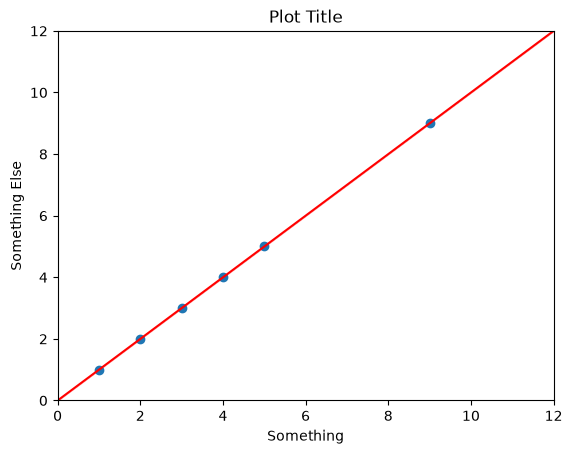

np.float64(1.0)

In [2]:
example_x = [1,2,3,4,5,9]
example_y = [1,2,3,4,5,9]

OLSlinearRegression(example_x, example_y, 0, 12, 0, 12, "Plot Title")


R^2: 0.7407467532467532


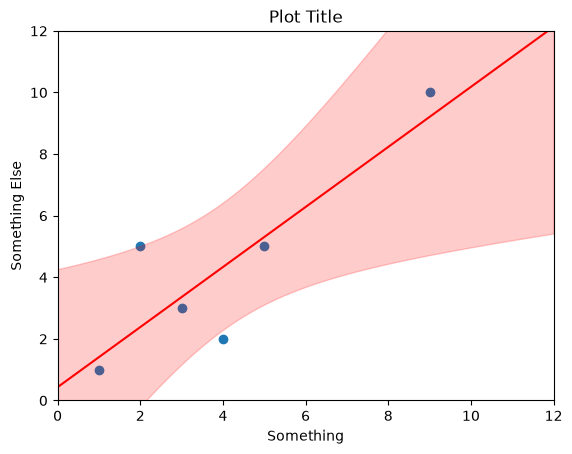

np.float64(0.7407467532467532)

In [3]:
example_x = [1,2,3,4,5,9]
example_y = [1,5,3,2,5,10]

OLSlinearRegression(example_x, example_y, 0, 12, 0, 12, "Plot Title")

### Real Data

In [4]:
FINANCE_BALLOT_2024_PATH = (
    PROCESSED
    / "finance_vs_ballot_support"
    / str(YEAR_2024)
    / "candidate_finance_ballot_analysis_2024.csv"
)

all_data = pd.read_csv(FINANCE_BALLOT_2024_PATH)


In [5]:
all_data

,year,district,source_candidate_name,mentions,mention_share,first_place_votes,first_place_share,total_ballot_weight,stv_threshold,is_viable,...,amount_share_medium,contribution_share_medium,amount_large,contribution_count_large,amount_share_large,contribution_share_large,amount_mega,contribution_count_mega,amount_share_mega,contribution_share_mega
0,2024,1,Timur Ender,16858.0,0.393226,3550.0,0.082807,42871.0,10718.0,True,...,0.196554,0.049206,15982.75,43,0.258579,0.034127,0.0,0,0.0,0.0
1,2024,1,Terrence Hayes,15967.0,0.372443,3975.0,0.092720,42871.0,10718.0,True,...,0.162765,0.030114,7431.02,21,0.205800,0.021807,0.0,0,0.0,0.0
2,2024,1,Loretta Smith,17984.0,0.419491,5586.0,0.130298,42871.0,10718.0,True,...,0.183518,0.069632,19104.96,51,0.436735,0.098646,0.0,0,0.0,0.0
3,2024,1,Deian Salazar,5262.0,0.122740,720.0,0.016795,42871.0,10718.0,False,...,0.144928,0.018519,0.00,0,0.000000,0.000000,0.0,0,0.0,0.0
4,2024,1,Noah Ernst,11606.0,0.270719,4052.0,0.094516,42871.0,10718.0,True,...,0.088508,0.012019,3353.18,8,0.258072,0.019231,0.0,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,2024,4,Chris Henry,3199.0,0.041699,301.0,0.003924,76717.0,19180.0,False,...,0.045668,0.001698,0.00,0,0.000000,0.000000,0.0,0,0.0,0.0
61,2024,4,Tony Morse,13246.0,0.172661,2004.0,0.026122,76717.0,19180.0,False,...,0.157171,0.057762,16371.98,42,0.391584,0.075812,0.0,0,0.0,0.0
62,2024,4,Olivia Clark,45205.0,0.589244,19138.0,0.249462,76717.0,19180.0,True,...,0.229007,0.088737,27073.00,74,0.283075,0.063140,0.0,0,0.0,0.0
63,2024,4,John Toran,8652.0,0.112778,1052.0,0.013713,76717.0,19180.0,False,...,0.000000,0.000000,0.00,0,0.000000,0.000000,0.0,0,0.0,0.0


In [6]:
all_data_3 = all_data[['candidate_key','mentions',
       'mention_share', 'first_place_votes', 'first_place_share',
       'total_ballot_weight', 'stv_threshold', 'is_viable','total_amount']]

#        'amount_micro', 'amount_small',
#        'amount_medium', 'amount_large', 'amount_mega', 'amount_share_micro',
#        'amount_share_small', 'amount_share_medium', 'amount_share_large',
#        'amount_share_mega', 'contribution_count_micro',
#        'contribution_count_small', 'contribution_count_medium',
#        'contribution_count_large', 'contribution_count_mega',
#        'contribution_share_micro', 'contribution_share_small',
#        'contribution_share_medium', 'contribution_share_large',
#        'contribution_share_mega', 'total_amount', 'total_contribution_count',
#        'average_contribution', 'median_contribution'

#I'm mostly leaving out contribution data until I get 2026 contribution data. 

In [7]:
SPENDING_2024_PATH = (
    spending_processed_dir(YEAR_2024, CONTEST)
    / "orestar_candidate_spending_profiles_wide.csv"
)

all_data_2 = pd.read_csv(SPENDING_2024_PATH)


### Start by checking the data quality (spoiler: it's not great)

In [8]:
all_data[all_data['candidate_key'].isna()]

,year,district,source_candidate_name,mentions,mention_share,first_place_votes,first_place_share,total_ballot_weight,stv_threshold,is_viable,...,amount_share_medium,contribution_share_medium,amount_large,contribution_count_large,amount_share_large,contribution_share_large,amount_mega,contribution_count_mega,amount_share_mega,contribution_share_mega


In [9]:
all_data_2[all_data_2['candidate_key'].isna()]

,year,contest_type,office,district,profile_key,candidate,spending_amount_micro,spending_amount_small,spending_amount_medium,spending_amount_large,...,average_expenditure,median_expenditure,min_expenditure,max_expenditure,std_expenditure,source_file_stem,source_candidate_name,canonical_candidate,candidate_key,linkage_status
7,2024,city_council,Portland City Council,1,2024|1|orestar|durphy,Durphy,1271.61,3310.35,8415.94,26454.38,...,284.494425,21.000,0.04,16300.00,1026.683289,Durphy,Durphy,NaN,NaN,unmatched_source_candidate
8,2024,city_council,Portland City Council,1,2024|1|orestar|mckenzie,McKenzie,127.25,235.54,1309.47,3754.50,...,139.147692,34.780,0.35,618.00,203.240027,McKenzie,McKenzie,NaN,NaN,unmatched_source_candidate
27,2024,city_council,Portland City Council,2,2024|2|orestar|burnell,Burnell,100.31,587.52,440.00,2271.99,...,162.897419,55.000,0.70,1650.00,344.556904,Burnell,Burnell,NaN,NaN,unmatched_source_candidate
28,2024,city_council,Portland City Council,2,2024|2|orestar|emerson,Emerson,124.16,245.75,115.00,1100.00,...,68.909130,14.850,0.79,750.00,165.297797,Emerson,Emerson,NaN,NaN,unmatched_source_candidate
29,2024,city_council,Portland City Council,2,2024|2|orestar|middleton,Middleton,88.84,764.60,2954.60,2835.37,...,114.541552,91.985,0.53,694.00,137.808240,Middleton,Middleton,NaN,NaN,unmatched_source_candidate
30,2024,city_council,Portland City Council,2,2024|2|orestar|sherman,Sherman,151.66,543.16,1722.62,1822.72,...,78.521481,23.830,0.53,442.72,111.592044,Sherman,Sherman,NaN,NaN,unmatched_source_candidate
47,2024,city_council,Portland City Council,3,2024|3|orestar|morse,Morse,769.15,2659.09,1875.44,25728.15,...,472.609709,55.000,1.58,22863.25,1854.397059,Morse,Morse,NaN,NaN,unmatched_source_candidate
48,2024,city_council,Portland City Council,3,2024|3|orestar|penson,Penson,453.88,2749.42,4666.73,23278.78,...,808.487472,161.695,2.10,14173.09,1802.183999,Penson,Penson,NaN,NaN,unmatched_source_candidate
71,2024,city_council,Portland City Council,4,2024|4|orestar|kaluba,Kaluba,11.38,0.00,0.00,313.62,...,108.333333,10.680,0.70,313.62,177.853484,Kaluba,Kaluba,NaN,NaN,unmatched_source_candidate
72,2024,city_council,Portland City Council,4,2024|4|orestar|underdahl,Underdahl,55.21,269.28,1172.28,390.00,...,82.033478,40.570,0.18,390.00,100.408038,Underdahl,Underdahl,NaN,NaN,unmatched_source_candidate


### Ok, this might be a problem, 10 of these names do not match real candidates, at least one due to human error

In [10]:
#I'm gonna just try and figure these out by hand, since there's only 10 of them. Here are my findings, code is immediately below:

#District 1:
# "Durphy" has gotta be Jamie Dunphy, 
# "McKenzie" dropped out, and is thus not in the ballot data, 
# And then we're missing spending data on Doug Clove, but he has donations, so it must exist (it's possible orestar just doens't have it, but that seems unlikely).   

# District 2:
# Dan Ryan had lots of donations (and won a seat!) and is missing from spending 
# There's 4 extra candidates in spending, all withdrew according to the wiki 

# District 3:
#These 3 were on the ballot, but we don't have spending data: ['Dan Gilk', 'Matthew (Matt) Anderson', 'Rex Burkholder']
#I might buy that Matt didn't spend anything (only raised $700, but Gilk was like $3500, and Rex was 5 figures)

#And then as far as spending data: 
#Penson was on the ballot in district 2?? 
#Morse was on the ballot in district 4? 
#Kezia got 6% of FPV, wiki thinks Brian Conley, Daniel DeMelo, and Patrick Hilton were all on the ballot too. 
#It's possible the site we're scraping didn't bother to list really minor candidates, but Kezia was the 4th place FPV, she really should be there.

#District 4
#Andra Vltavin - on the ballot, no spending data (only raised $800, might be fine)

#'Bob Callahan', 'Chloe Mason', 'Ciatta R Thompson' - all on the ballot, but not in our mentions/FPV data 
#'Jeremy Beausoleil Smith', 'Kaluba', and 'Underdahl' withdrew, so that's fine 

In [11]:
dist = 1
ballot_list = all_data[all_data['district'] == dist]['source_candidate_name']
spending_list = all_data_2[all_data_2['district'] == dist]['candidate']

print([x for x in ballot_list if x not in set(spending_list)])
print([x for x in spending_list if x not in set(ballot_list)])

['Jamie Dunphy', 'Doug Clove']
['Durphy', 'McKenzie']


In [12]:
all_data[all_data['district'] == 1].sort_values("source_candidate_name")  #note: all_data gets overwritten in a merge a few lines down, so if you want to change this, run it from the beginning again

,year,district,source_candidate_name,mentions,mention_share,first_place_votes,first_place_share,total_ballot_weight,stv_threshold,is_viable,...,amount_share_medium,contribution_share_medium,amount_large,contribution_count_large,amount_share_large,contribution_share_large,amount_mega,contribution_count_mega,amount_share_mega,contribution_share_mega
11,2024,1,Candace Avalos,22267.0,0.519395,8297.0,0.193534,42871.0,10718.0,True,...,0.120834,0.022088,9946.04,25,0.168881,0.016734,3787.65,2,0.064313,0.001339
8,2024,1,Cayle Tern,9061.0,0.211355,711.0,0.016585,42871.0,10718.0,False,...,0.101420,0.009585,350.00,1,0.047329,0.003195,0.00,0,0.000000,0.000000
12,2024,1,David Linn,9324.0,0.217490,1111.0,0.025915,42871.0,10718.0,False,...,0.168516,0.030769,499.99,1,0.104666,0.007692,0.00,0,0.000000,0.000000
3,2024,1,Deian Salazar,5262.0,0.122740,720.0,0.016795,42871.0,10718.0,False,...,0.144928,0.018519,0.00,0,0.000000,0.000000,0.00,0,0.000000,0.000000
6,2024,1,Doug Clove,7593.0,0.177113,1698.0,0.039607,42871.0,10718.0,False,...,0.166113,0.076923,980.00,2,0.651163,0.153846,0.00,0,0.000000,0.000000
5,2024,1,Jamie Dunphy,18470.0,0.430827,5064.0,0.118122,42871.0,10718.0,True,...,0.135467,0.020853,8168.00,21,0.232213,0.019905,2291.25,1,0.065139,0.000948
7,2024,1,Joe Furi,4070.0,0.094936,355.0,0.008281,42871.0,10718.0,False,...,0.000000,0.000000,500.00,1,0.614288,0.090909,0.00,0,0.000000,0.000000
2,2024,1,Loretta Smith,17984.0,0.419491,5586.0,0.130298,42871.0,10718.0,True,...,0.183518,0.069632,19104.96,51,0.436735,0.098646,0.00,0,0.000000,0.000000
4,2024,1,Noah Ernst,11606.0,0.270719,4052.0,0.094516,42871.0,10718.0,True,...,0.088508,0.012019,3353.18,8,0.258072,0.019231,0.00,0,0.000000,0.000000
10,2024,1,Steph Routh,20440.0,0.476779,3894.0,0.090831,42871.0,10718.0,True,...,0.140790,0.025823,12210.00,31,0.160644,0.015696,0.00,0,0.000000,0.000000


In [13]:
all_data_2[all_data_2['district'] == 1].sort_values("candidate")

,year,contest_type,office,district,profile_key,candidate,spending_amount_micro,spending_amount_small,spending_amount_medium,spending_amount_large,...,average_expenditure,median_expenditure,min_expenditure,max_expenditure,std_expenditure,source_file_stem,source_candidate_name,canonical_candidate,candidate_key,linkage_status
0,2024,city_council,Portland City Council,1,2024|1|candace avalos,Candace Avalos,1353.50,7027.16,12667.39,51604.78,...,377.067936,78.260,0.08,21297.66,1364.949484,Avalos,Avalos,Candace Avalos,2024|1|candace avalos,matched_to_official_candidate
1,2024,city_council,Portland City Council,1,2024|1|cayle tern,Cayle Tern,195.10,1104.67,1627.98,10274.96,...,183.370972,80.000,0.18,868.60,243.060876,Tern,Tern,Cayle Tern,2024|1|cayle tern,matched_to_official_candidate
2,2024,city_council,Portland City Council,1,2024|1|david linn,David Linn,415.06,278.93,1540.00,2942.50,...,78.431667,15.990,0.18,750.00,153.081951,Linn,Linn,David Linn,2024|1|david linn,matched_to_official_candidate
3,2024,city_council,Portland City Council,1,2024|1|deian salazar,Deian Salazar,404.30,829.16,1845.20,1055.76,...,70.090132,20.825,0.18,1192.43,154.362181,Salazar,Salazar,Deian Salazar,2024|1|deian salazar,matched_to_official_candidate
7,2024,city_council,Portland City Council,1,2024|1|orestar|durphy,Durphy,1271.61,3310.35,8415.94,26454.38,...,284.494425,21.000,0.04,16300.00,1026.683289,Durphy,Durphy,NaN,NaN,unmatched_source_candidate
4,2024,city_council,Portland City Council,1,2024|1|joe furi,Joe Furi,26.25,110.00,283.75,330.00,...,93.750000,55.000,3.50,330.00,111.281577,Furi,Furi,Joe Furi,2024|1|joe furi,matched_to_official_candidate
5,2024,city_council,Portland City Council,1,2024|1|loretta smith,Loretta Smith,4035.24,23590.11,53752.79,134672.06,...,969.629940,100.895,0.07,48200.00,3599.745502,Smith,Smith,Loretta Smith,2024|1|loretta smith,matched_to_official_candidate
8,2024,city_council,Portland City Council,1,2024|1|orestar|mckenzie,McKenzie,127.25,235.54,1309.47,3754.50,...,139.147692,34.780,0.35,618.00,203.240027,McKenzie,McKenzie,NaN,NaN,unmatched_source_candidate
6,2024,city_council,Portland City Council,1,2024|1|noah ernst,Noah Ernst,145.73,1723.32,4387.51,22879.63,...,441.382794,195.000,0.18,10200.00,1113.966186,Ernst,Ernst,Noah Ernst,2024|1|noah ernst,matched_to_official_candidate
9,2024,city_council,Portland City Council,1,2024|1|steph routh,Steph Routh,1885.16,4531.86,5169.86,23150.81,...,352.813584,8.720,0.20,31881.49,1821.093465,Routh,Routh,Steph Routh,2024|1|steph routh,matched_to_official_candidate


In [14]:
#I'll also note that 3 candidates in district 1 were on the ballot, and do not appear in EITHER data set:

#Michael (Mike) Sands
#Joe Allen 
#Peggy Sue Owens

#None of them are viable, but this is very incomplete data. 

### Nevertheless, let's keep going:

Some other odities show up in the data we do have:

Loretta Smith is recorded as having spent $1.46 million on her campaign. Could be legit, but that's very high. 
Steve Novick spent $1 million. Also high. No one else spent more than $310K.

Only one candidate spent less than they recieved according to this data, which is a bigger sign to me that something is wrong here. 

In [15]:
# all_data = pd.merge(all_data_3, all_data_2, on = 'candidate_key', how='left')   
all_data = pd.merge(all_data_3, all_data_2, on = 'candidate_key', how='inner')      #I've chosen an inner merge to exclude any candidate we don't have both data sets for

In [16]:
all_data_2['calculated_total_spending'] = all_data_2[['spending_amount_micro', 'spending_amount_small',
       'spending_amount_medium', 'spending_amount_large',
       'spending_amount_mega']].sum(axis=1)

all_data_2[all_data_2['district'] == 1][['candidate','total_spending','calculated_total_spending','spending_amount_micro', 'spending_amount_small',
       'spending_amount_medium', 'spending_amount_large',
       'spending_amount_mega']]

,candidate,total_spending,calculated_total_spending,spending_amount_micro,spending_amount_small,spending_amount_medium,spending_amount_large,spending_amount_mega
0,Candace Avalos,177221.93,177221.93,1353.50,7027.16,12667.39,51604.78,104569.10
1,Cayle Tern,13202.71,13202.71,195.10,1104.67,1627.98,10274.96,0.00
2,David Linn,5176.49,5176.49,415.06,278.93,1540.00,2942.50,0.00
3,Deian Salazar,5326.85,5326.85,404.30,829.16,1845.20,1055.76,1192.43
4,Joe Furi,750.00,750.00,26.25,110.00,283.75,330.00,0.00
5,Loretta Smith,1464141.21,1464141.21,4035.24,23590.11,53752.79,134672.06,1248091.01
6,Noah Ernst,60028.06,60028.06,145.73,1723.32,4387.51,22879.63,30891.87
7,Durphy,111237.32,111237.32,1271.61,3310.35,8415.94,26454.38,71785.04
8,McKenzie,5426.76,5426.76,127.25,235.54,1309.47,3754.50,0.00
9,Steph Routh,201809.37,201809.37,1885.16,4531.86,5169.86,23150.81,167071.68


In [17]:
all_data[['candidate_key','total_amount','total_spending']]

,candidate_key,total_amount,total_spending
0,2024|1|timur ender,61809.84,157642.42
1,2024|1|terrence hayes,36108.05,92626.13
2,2024|1|loretta smith,43744.96,1464141.21
3,2024|1|deian salazar,1380.00,5326.85
4,2024|1|noah ernst,12993.18,60028.06
5,2024|1|joe furi,813.95,750.00
6,2024|1|cayle tern,7395.00,13202.71
7,2024|1|thomas shervey,1060.00,2223.98
8,2024|1|steph routh,76006.71,201809.37
9,2024|1|candace avalos,58893.80,177221.93


In [18]:
all_data[['candidate_key','total_amount','total_spending']][all_data['total_amount'] > all_data['total_spending']]

,candidate_key,total_amount,total_spending
5,2024|1|joe furi,813.95,750.0


In [19]:
all_data[['candidate_key','total_amount','total_spending']][all_data['total_spending'] > 300_000]

,candidate_key,total_amount,total_spending
2,2024|1|loretta smith,43744.96,1464141.21
32,2024|3|steve novick,87240.55,1081644.06
37,2024|3|tiffany koyama lane,88689.62,308922.62


In [20]:
all_data[all_data['district'] == 1][['mention_share', 'first_place_share']].sum()

mention_share        3.180378
first_place_share    0.761261
dtype: float64

In [21]:
#Candidates rank up to 6, so that tally at least is fine, knowing we're missing major candidates. 

### So we need to look into the data sources more, but again, let's keep going so we have the whole pipeline ready. 

### Analysis

In [22]:
save_dir = ROOT / "outputs" / "kevin_reg_figures"
save_dir.mkdir(parents=True, exist_ok=True)
save_dir = str(save_dir) + "/"


In [23]:
# all_data = all_data.fillna(0)    #ideally we don't need this, I think the Nans only come from other errors that need to be corrected/removed, not zeroed out. 


mention_share vs spending_amount_micro:

R^2: 0.21301298489060683


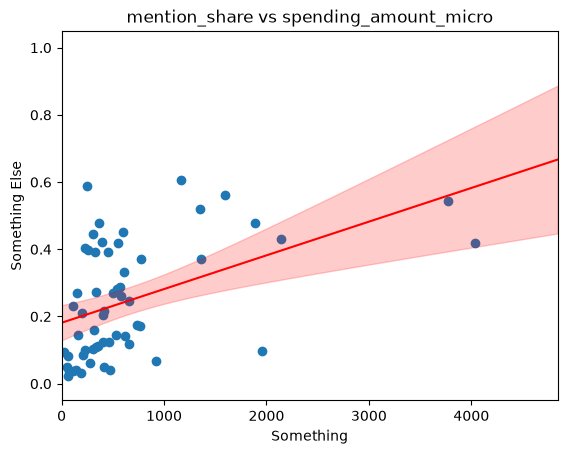


mention_share vs spending_amount_small:

R^2: 0.298729478779877


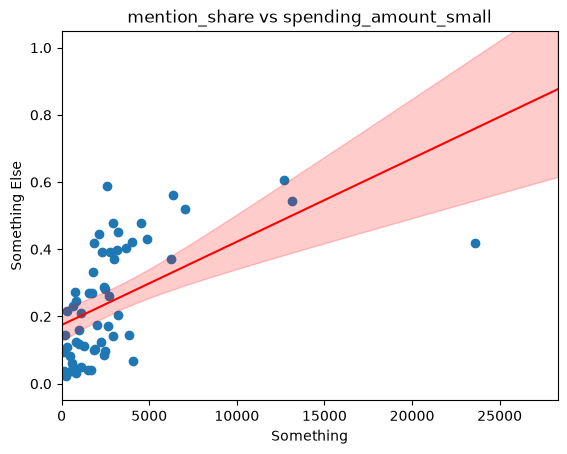


mention_share vs spending_amount_medium:

R^2: 0.16884560693976258


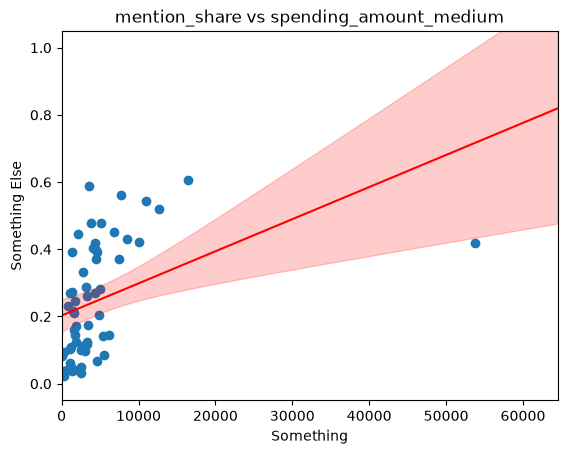


mention_share vs spending_amount_large:

R^2: 0.29950628560332837


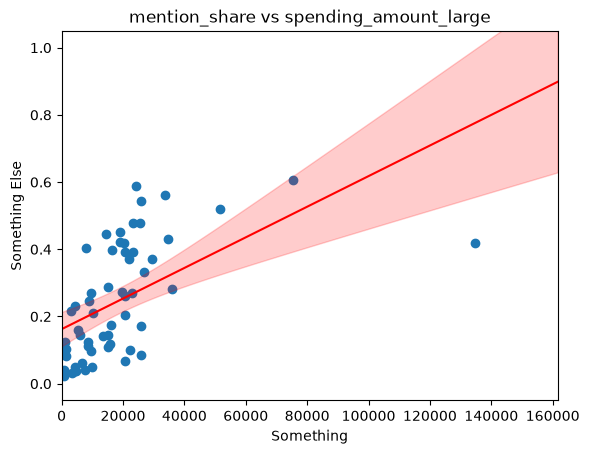


mention_share vs spending_amount_mega:

R^2: 0.24387978871763316


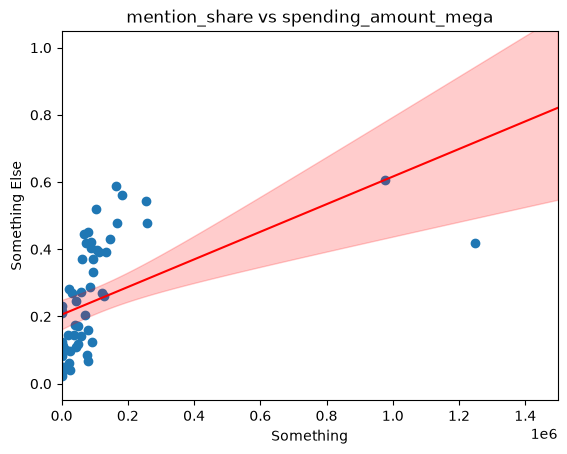


mention_share vs spending_amount_share_micro:

R^2: 0.153880430151077


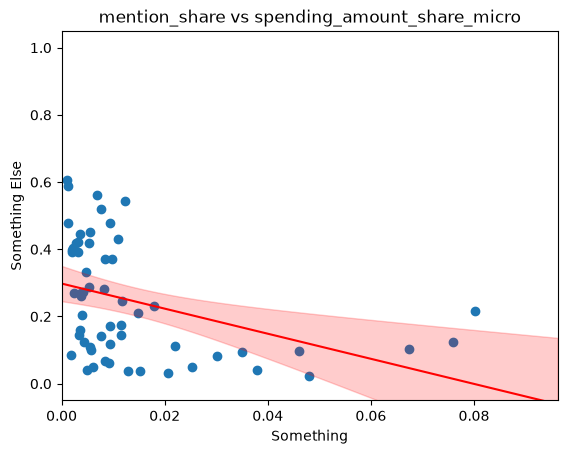


mention_share vs spending_amount_share_small:

R^2: 0.15720048450170765


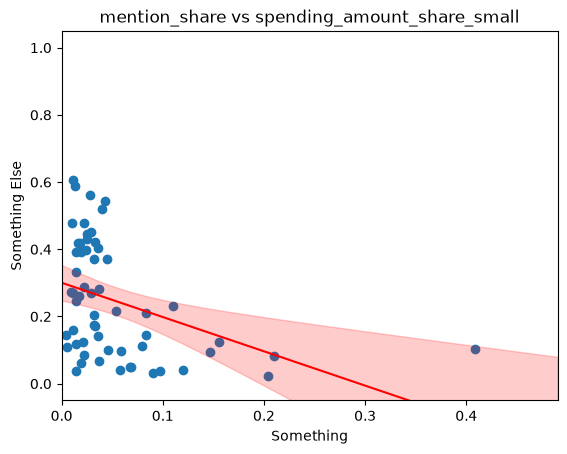


mention_share vs spending_amount_share_medium:

R^2: 0.1921958758177732


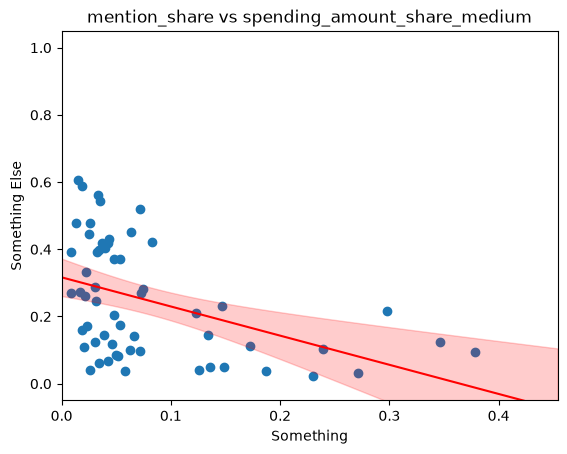


mention_share vs spending_amount_share_large:

R^2: 0.2512615165901303


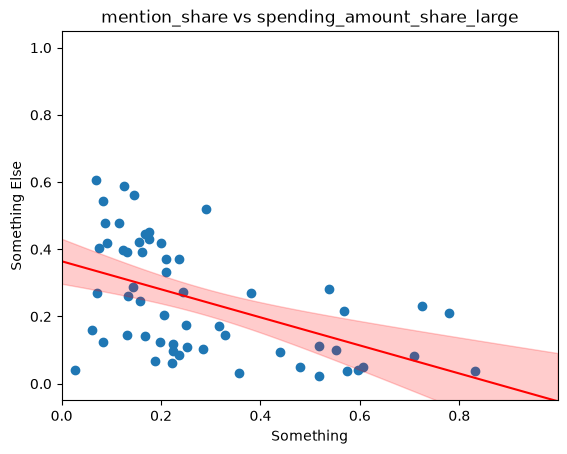


mention_share vs spending_amount_share_mega:

R^2: 0.31129530683149564


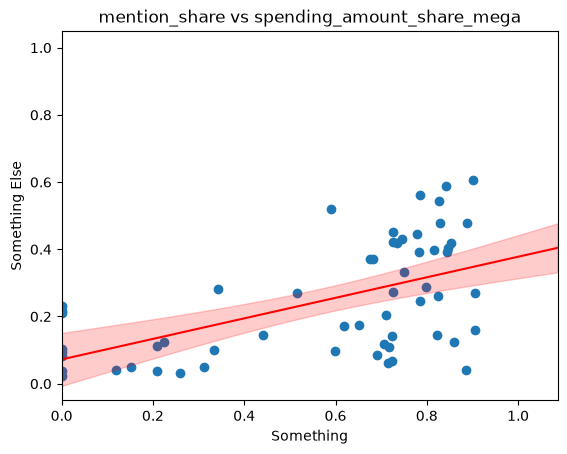


mention_share vs spending_count_micro:

R^2: 0.22091935809167795


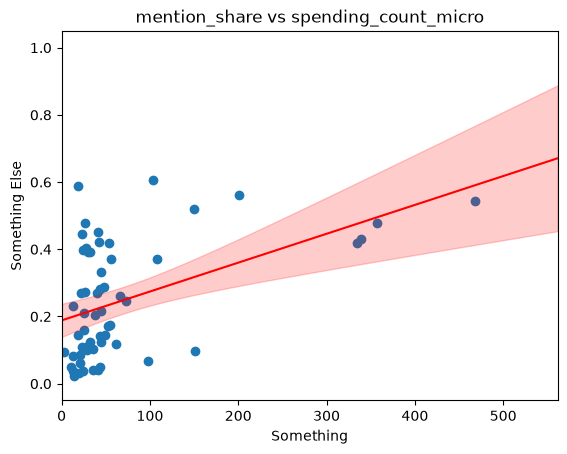


mention_share vs spending_count_small:

R^2: 0.3055105037085699


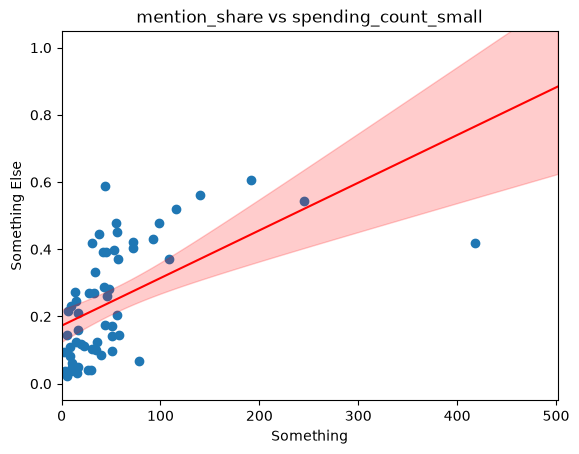


mention_share vs spending_count_medium:

R^2: 0.1747452631012667


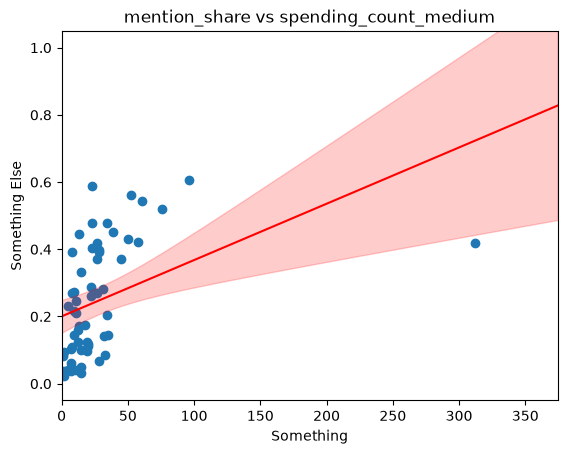


mention_share vs spending_count_large:

R^2: 0.25604160522520847


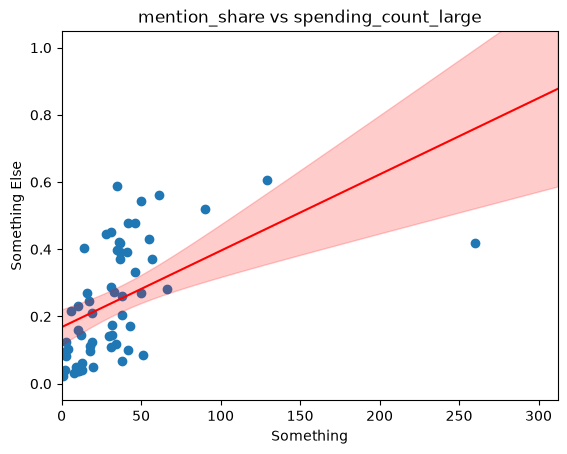


mention_share vs spending_count_mega:

R^2: 0.3756507013448962


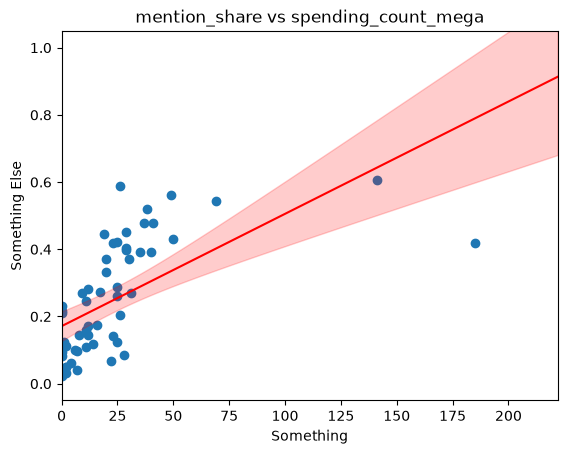


mention_share vs spending_count_share_micro:

R^2: 0.11076518893432696


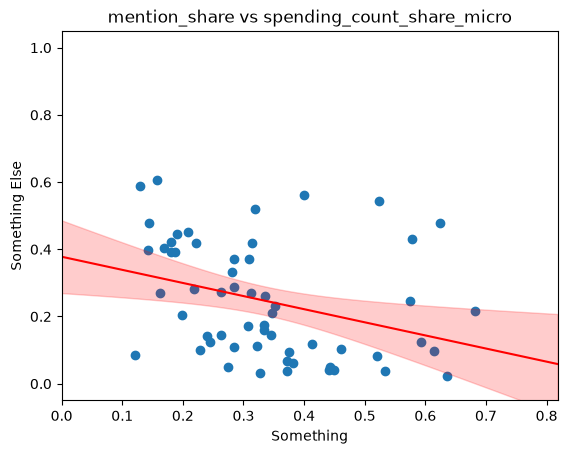


mention_share vs spending_count_share_small:

R^2: 0.03343082965713162


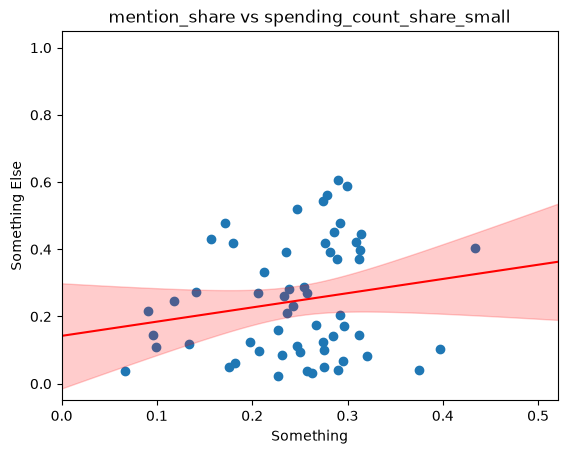


mention_share vs spending_count_share_medium:

R^2: 0.0004305757649254449


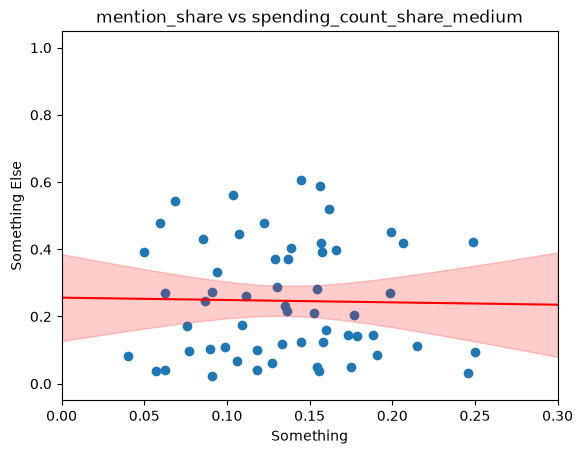


mention_share vs spending_count_share_large:

R^2: 5.1678235370555825e-05


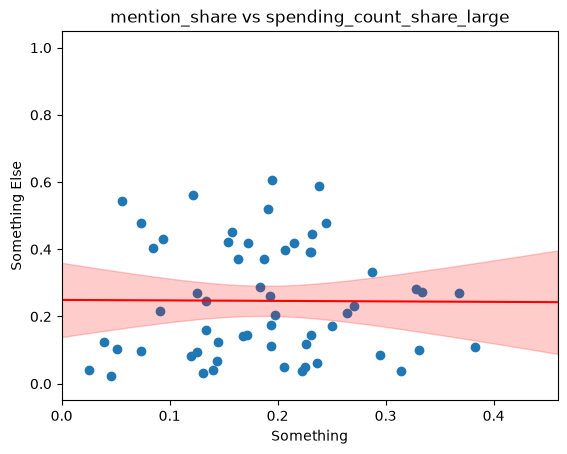


mention_share vs spending_count_share_mega:

R^2: 0.28649832022989485


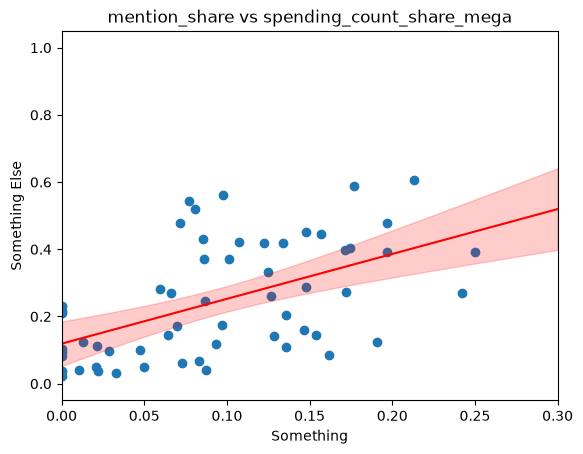


mention_share vs total_spending:

R^2: 0.2538150162310969


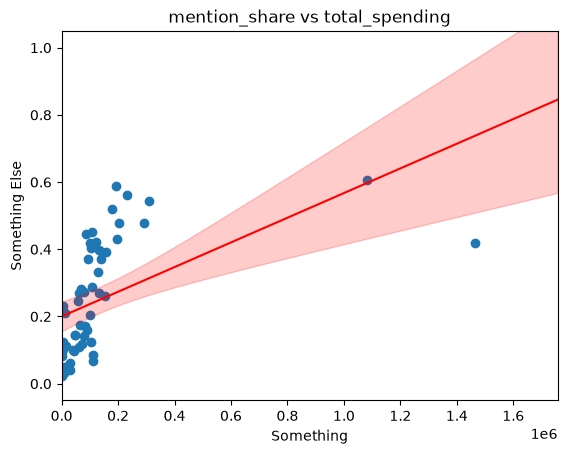


mention_share vs expenditure_count:

R^2: 0.3144815338525899


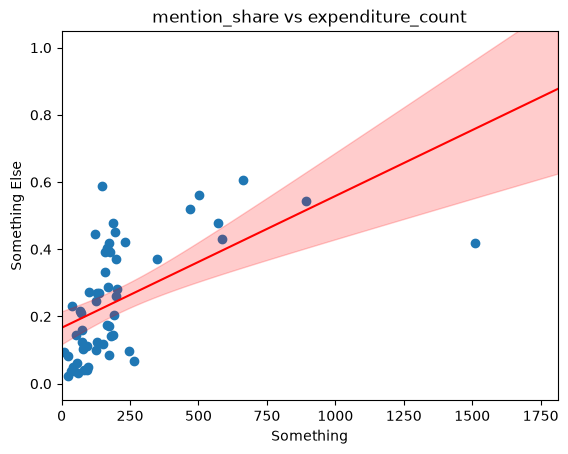


mention_share vs average_expenditure:

R^2: 0.29660181061703117


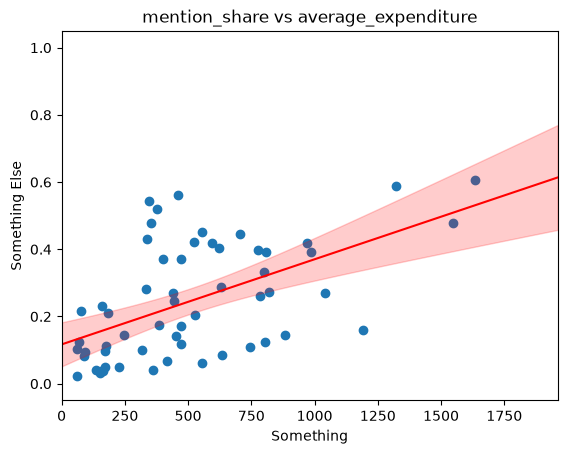


mention_share vs median_expenditure:

R^2: 0.03222797504034014


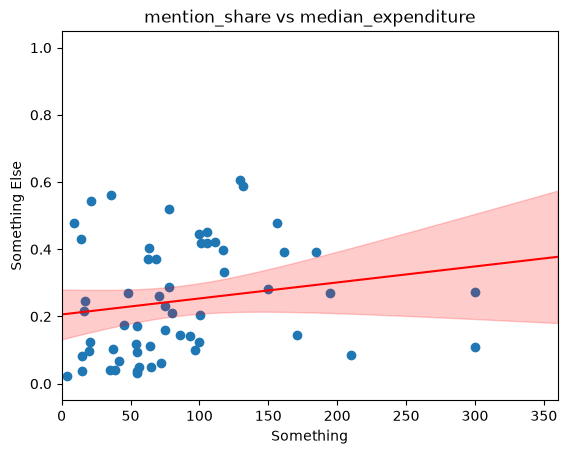


mention_share vs min_expenditure:

R^2: 0.03436878466509952


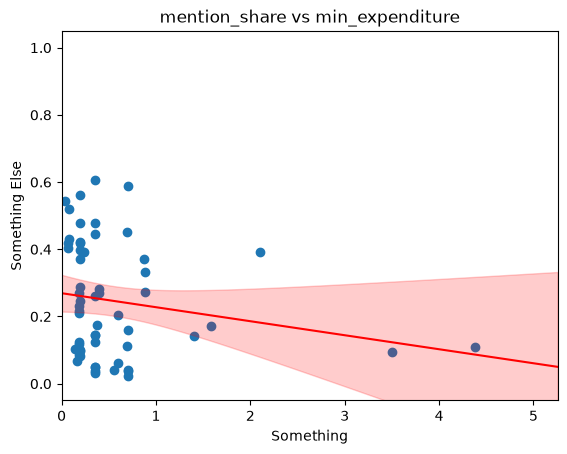


mention_share vs max_expenditure:

R^2: 0.44321957868947925


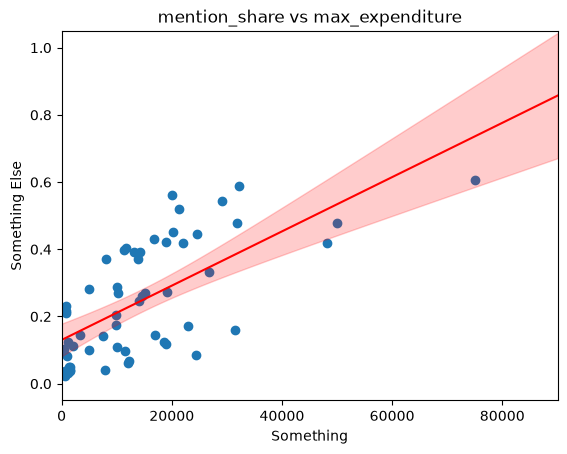


mention_share vs std_expenditure:

R^2: 0.347577050740573


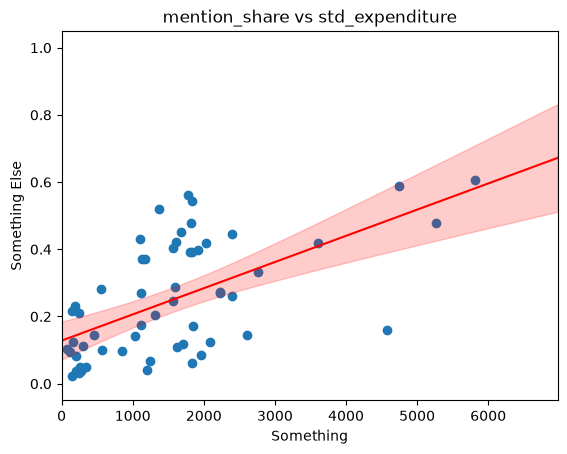


first_place_share vs spending_amount_micro:

R^2: 0.22228910832287008


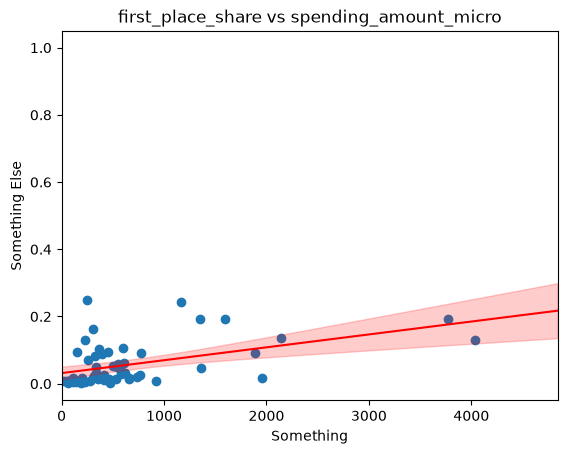


first_place_share vs spending_amount_small:

R^2: 0.3487763208497138


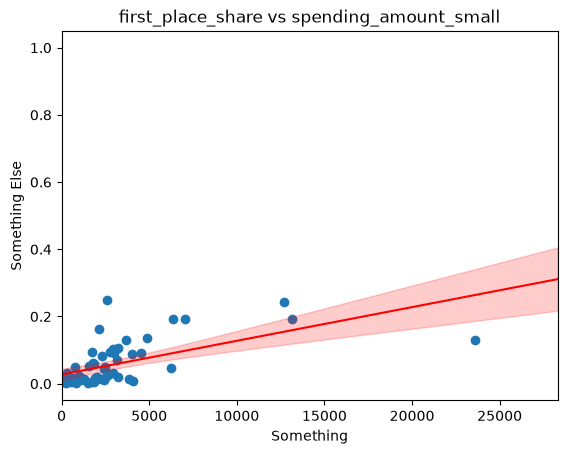


first_place_share vs spending_amount_medium:

R^2: 0.1923501059892846


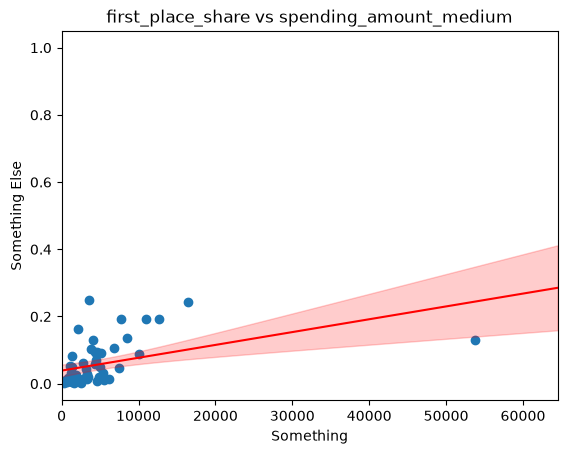


first_place_share vs spending_amount_large:

R^2: 0.32172026957014677


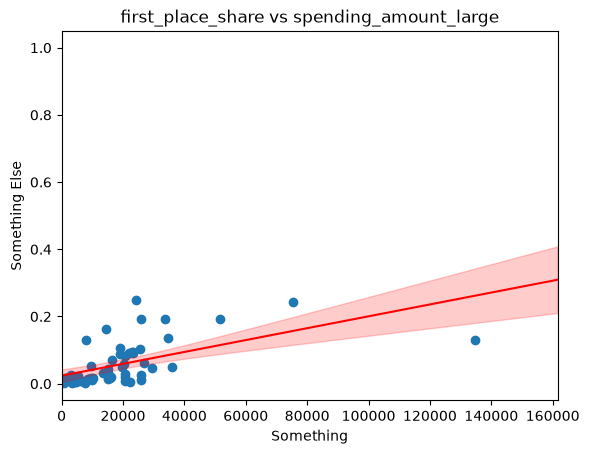


first_place_share vs spending_amount_mega:

R^2: 0.29594695064103826


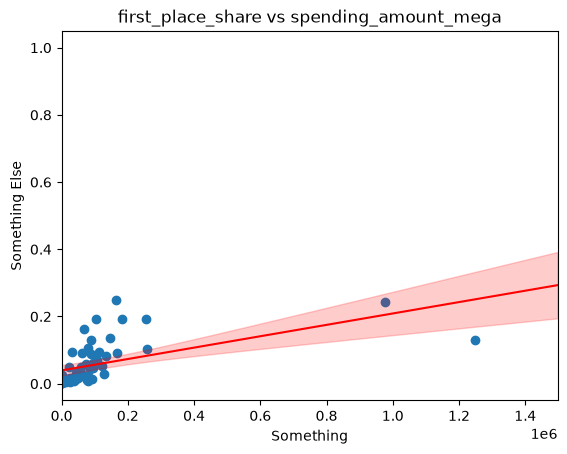


first_place_share vs spending_amount_share_micro:

R^2: 0.11467657822044652


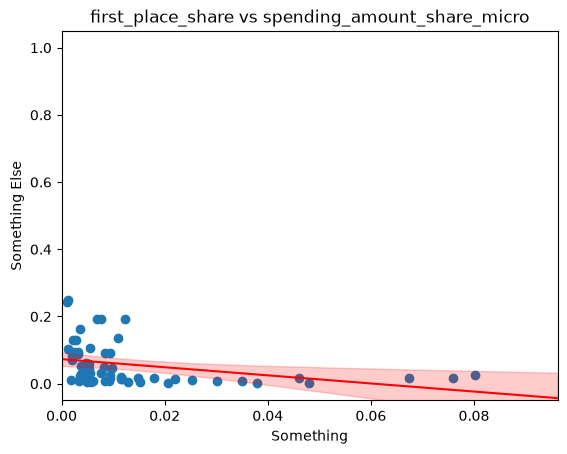


first_place_share vs spending_amount_share_small:

R^2: 0.09839270292629587


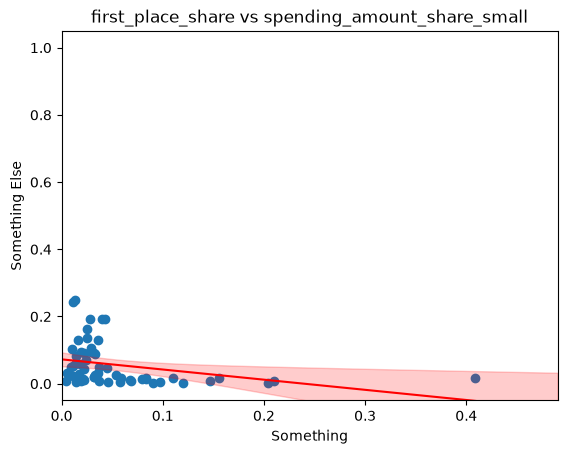


first_place_share vs spending_amount_share_medium:

R^2: 0.13666990158849868


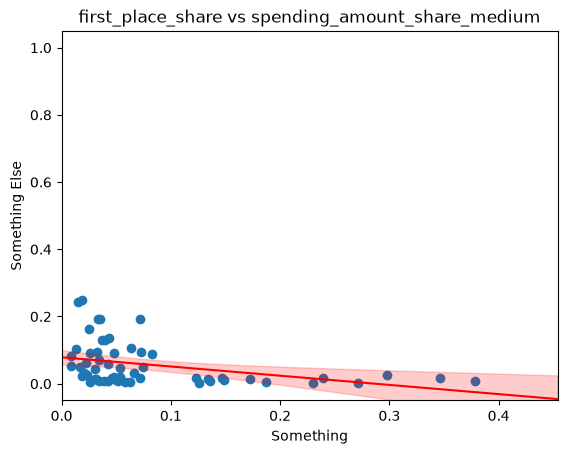


first_place_share vs spending_amount_share_large:

R^2: 0.19673647741060096


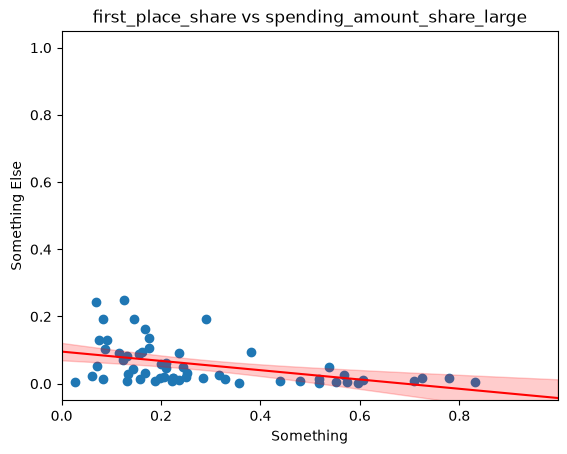


first_place_share vs spending_amount_share_mega:

R^2: 0.2306475663605415


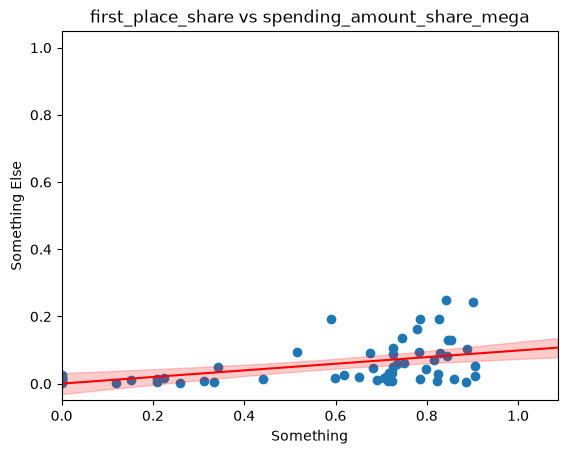


first_place_share vs spending_count_micro:

R^2: 0.22383507439976102


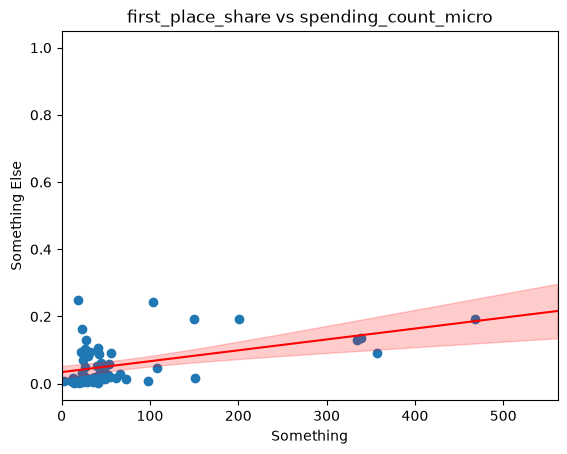


first_place_share vs spending_count_small:

R^2: 0.34686505271598767


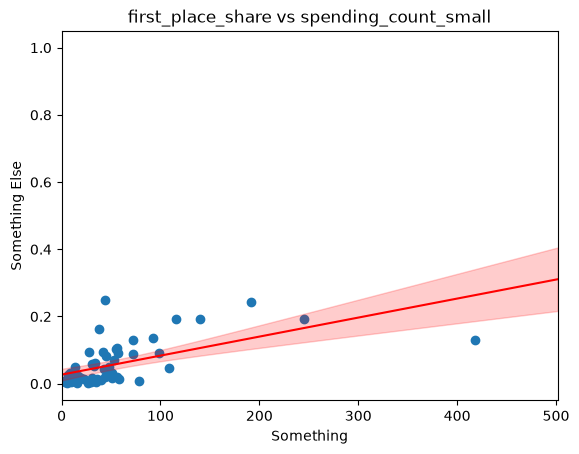


first_place_share vs spending_count_medium:

R^2: 0.1968575801866299


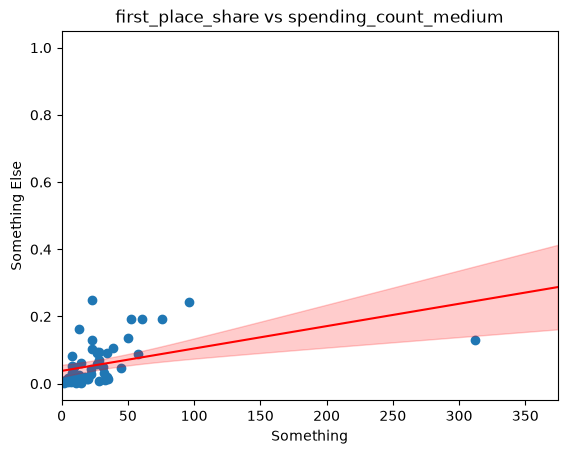


first_place_share vs spending_count_large:

R^2: 0.272153795954433


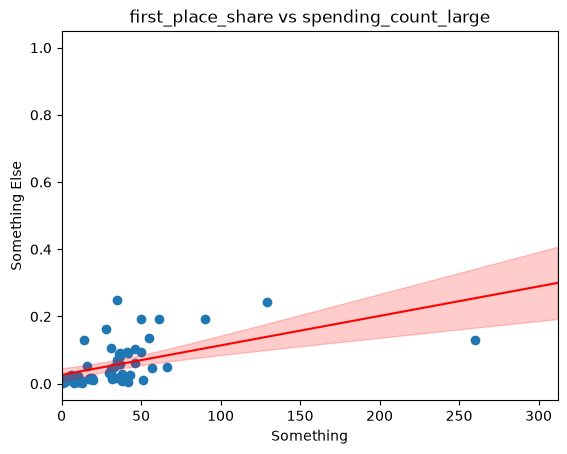


first_place_share vs spending_count_mega:

R^2: 0.4074423362526155


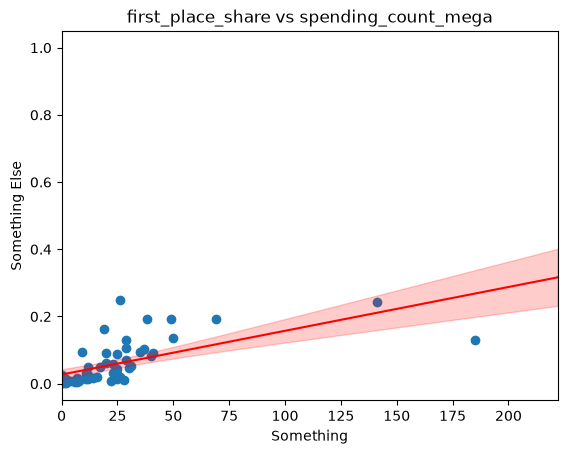


first_place_share vs spending_count_share_micro:

R^2: 0.09664959133123874


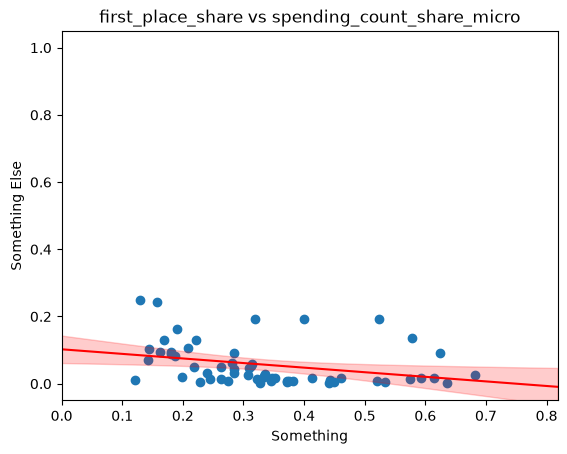


first_place_share vs spending_count_share_small:

R^2: 0.05216414475692355


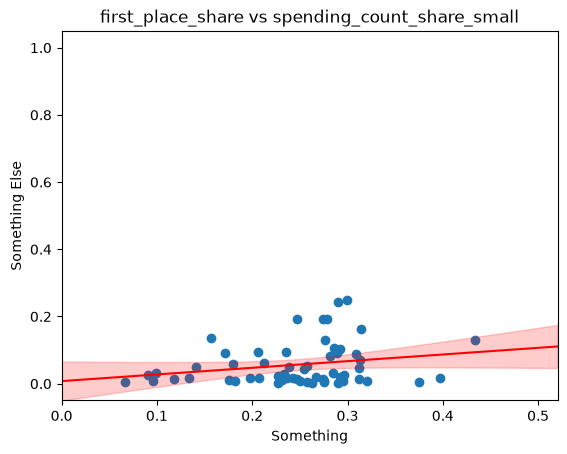


first_place_share vs spending_count_share_medium:

R^2: 8.294459759961015e-05


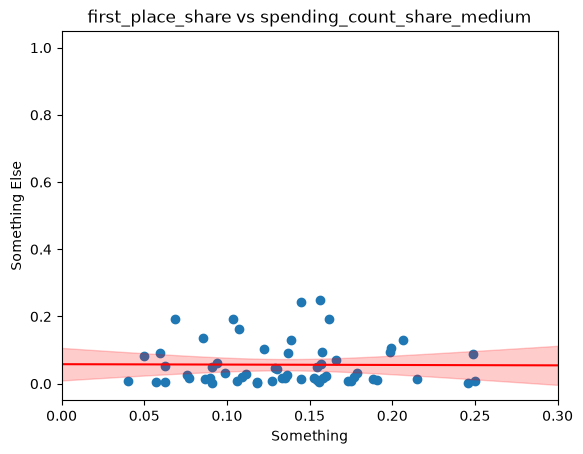


first_place_share vs spending_count_share_large:

R^2: 0.000700486601004191


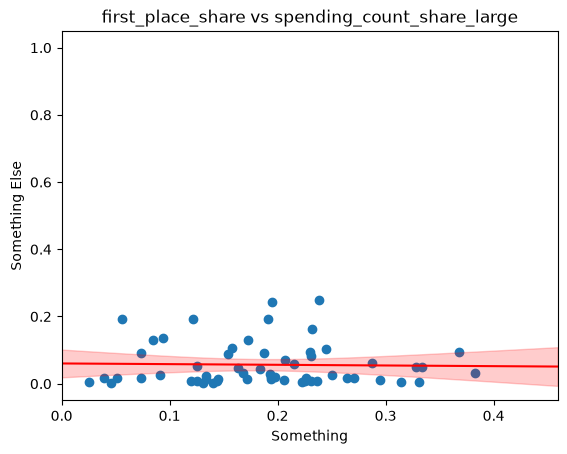


first_place_share vs spending_count_share_mega:

R^2: 0.20675569853524445


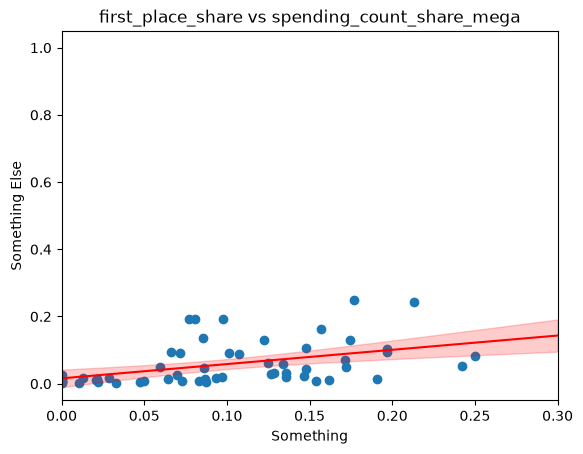


first_place_share vs total_spending:

R^2: 0.303719981884202


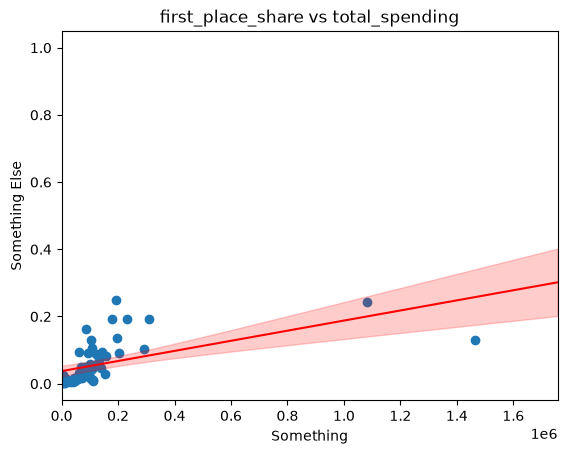


first_place_share vs expenditure_count:

R^2: 0.33874496996196


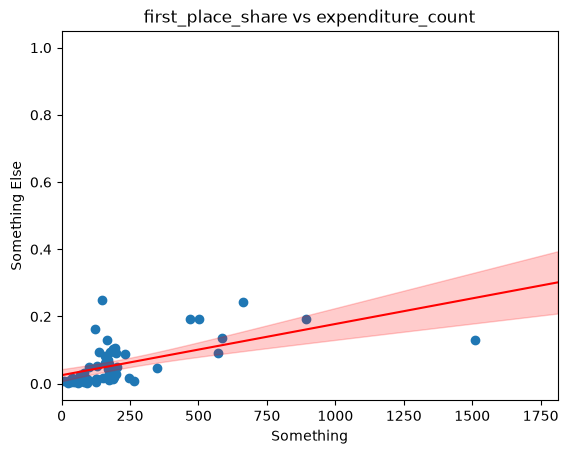


first_place_share vs average_expenditure:

R^2: 0.26276143267108


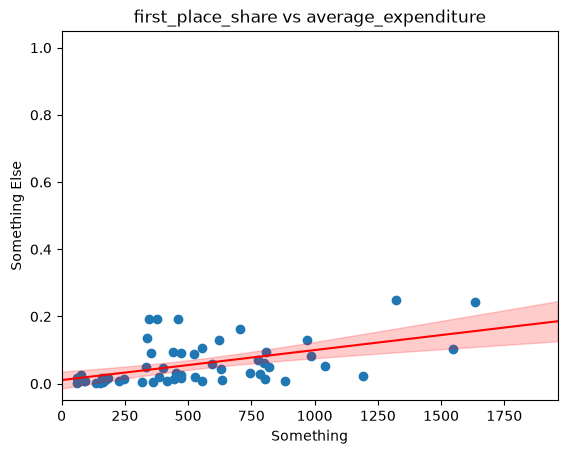


first_place_share vs median_expenditure:

R^2: 0.022695464420276923


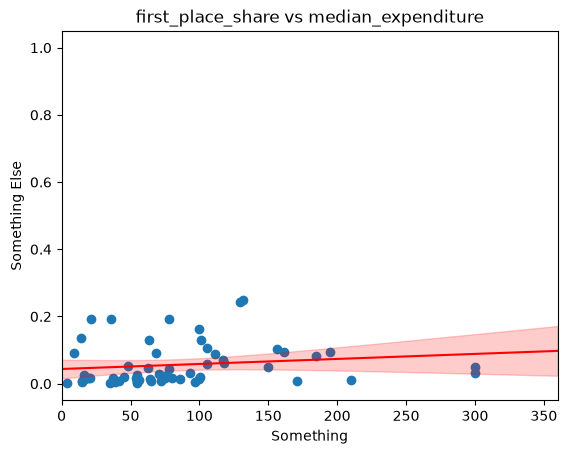


first_place_share vs min_expenditure:

R^2: 0.01662876817601966


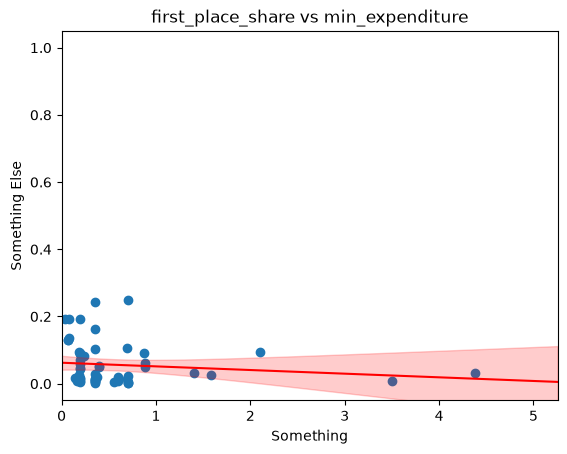


first_place_share vs max_expenditure:

R^2: 0.4504890070804759


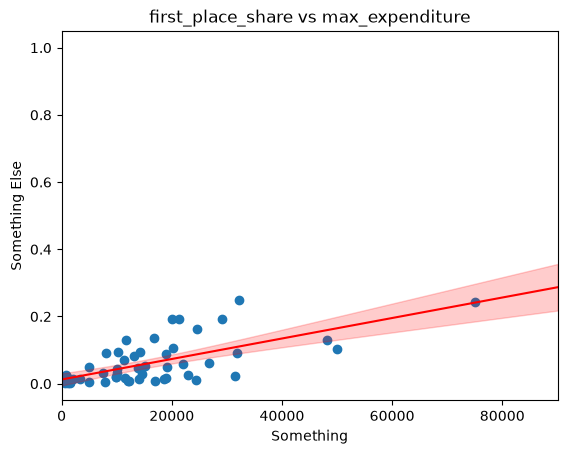


first_place_share vs std_expenditure:

R^2: 0.34202781241292923


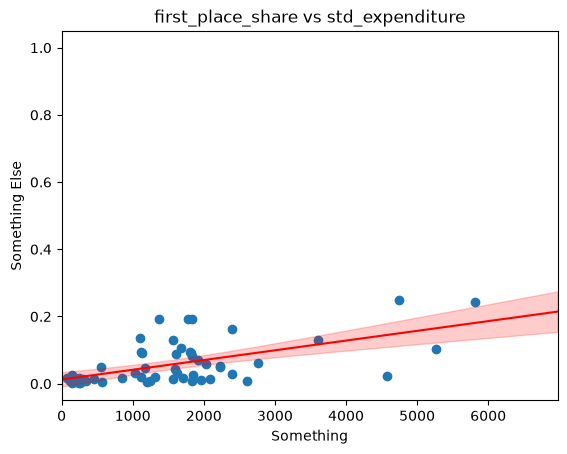

In [24]:
# independent_vars = all_data.columns[13:]
independent_vars = all_data.columns[15:-4]                  #define all the independent variables (financial)
dependent_vars = ['mention_share','first_place_share']      #define all the dependent variables (election performance metrics)

#Dictionaries!
r2_values = {}
pearsons = {}
spearmans = {}
pearsons_p_value = {}
spearmans_p_value = {}

#Does a regression for each independant variable's relationship with each dependent variable 
for y_name in dependent_vars:
    y_data = list(all_data[y_name])
    r2_values[y_name] = []
    pearsons[y_name] = []
    spearmans[y_name] = []
    pearsons_p_value[y_name] = []
    spearmans_p_value[y_name] = []
    for x_name in independent_vars:
        x_data = list(all_data[x_name])
        x_min = min(0, min(x_data))  #don't think any of these variables are negative, but just to be safe 
        x_max = max(x_data) * 1.2
        y_min = -0.05
        y_max = 1.05
        title = y_name + " vs " + x_name 
        print("\n" + title + ":\n")

        # print("Debug:", x_data, y_data)
        r2_values[y_name].append(OLSlinearRegression(x_data, y_data, x_min, x_max, y_min, y_max, title, saveName = save_dir + title, colors=[]))   #linear regression 

        pearson_corr, pearson_p = pearsonr(x_data, y_data)     #pearson coefficients + p value
        spearman_corr, spearman_p = spearmanr(x_data, y_data)  #spearman coefficients + p value

        pearsons[y_name].append(pearson_corr)
        spearmans[y_name].append(spearman_corr)
        pearsons_p_value[y_name].append(pearson_p)
        spearmans_p_value[y_name].append(spearman_p)

#summarize it all as a data frame
data_summary = pd.DataFrame({
    "variable": independent_vars,
    "mentions r2": r2_values[dependent_vars[0]], 
    "mentions pearson": pearsons[dependent_vars[0]], 
    "mentions pearson p value": pearsons_p_value[dependent_vars[0]],
    "mentions spearman": spearmans[dependent_vars[0]], 
    "mentions spearman p value": spearmans_p_value[dependent_vars[0]],
    "FPV r2": r2_values[dependent_vars[1]], 
    "FPV pearson": pearsons[dependent_vars[1]], 
    "FPV spearman": spearmans[dependent_vars[1]],
    "FPV spearman": spearmans[dependent_vars[1]], 
    "FPV spearman p value": spearmans_p_value[dependent_vars[1]]
})

In [25]:
data_summary

,variable,mentions r2,mentions pearson,mentions pearson p value,mentions spearman,mentions spearman p value,FPV r2,FPV pearson,FPV spearman,FPV spearman p value
0,spending_amount_micro,0.213013,0.461533,2.657469e-04,0.503768,5.547487e-05,0.222289,0.471475,0.496816,7.282541e-05
1,spending_amount_small,0.298729,0.546562,9.056087e-06,0.678489,4.843707e-09,0.348776,0.590573,0.665139,1.232627e-08
2,spending_amount_medium,0.168846,0.410908,1.355047e-03,0.643791,4.995576e-08,0.192350,0.438577,0.626073,1.473303e-07
3,spending_amount_large,0.299506,0.547272,8.769082e-06,0.697868,1.141232e-09,0.321720,0.567204,0.698668,1.072515e-09
4,spending_amount_mega,0.243880,0.493842,8.167237e-05,0.774171,1.023023e-12,0.295947,0.544010,0.762406,3.571575e-12
5,spending_amount_share_micro,0.153880,-0.392276,2.322660e-03,-0.524439,2.383010e-05,0.114677,-0.338639,-0.534283,1.562449e-05
6,spending_amount_share_small,0.157200,-0.396485,2.061948e-03,-0.447168,4.329723e-04,0.098393,-0.313676,-0.451106,3.795575e-04
7,spending_amount_share_medium,0.192196,-0.438402,5.772154e-04,-0.474607,1.672038e-04,0.136670,-0.369689,-0.473930,1.713411e-04
8,spending_amount_share_large,0.251262,-0.501260,6.123970e-05,-0.548187,8.411761e-06,0.196736,-0.443550,-0.519149,2.973929e-05
9,spending_amount_share_mega,0.311295,0.557938,5.357745e-06,0.583208,1.553745e-06,0.230648,0.480258,0.553886,6.473557e-06


In [26]:
#With color!
data_summary.style.background_gradient(subset=["mentions r2"], cmap="Blues").background_gradient(subset=["FPV r2"], cmap="Greens")

,variable,mentions r2,mentions pearson,mentions pearson p value,mentions spearman,mentions spearman p value,FPV r2,FPV pearson,FPV spearman,FPV spearman p value
0,spending_amount_micro,0.213013,0.461533,0.000266,0.503768,0.000055,0.222289,0.471475,0.496816,0.000073
1,spending_amount_small,0.298729,0.546562,0.000009,0.678489,0.000000,0.348776,0.590573,0.665139,0.000000
2,spending_amount_medium,0.168846,0.410908,0.001355,0.643791,0.000000,0.192350,0.438577,0.626073,0.000000
3,spending_amount_large,0.299506,0.547272,0.000009,0.697868,0.000000,0.321720,0.567204,0.698668,0.000000
4,spending_amount_mega,0.243880,0.493842,0.000082,0.774171,0.000000,0.295947,0.544010,0.762406,0.000000
5,spending_amount_share_micro,0.153880,-0.392276,0.002323,-0.524439,0.000024,0.114677,-0.338639,-0.534283,0.000016
6,spending_amount_share_small,0.157200,-0.396485,0.002062,-0.447168,0.000433,0.098393,-0.313676,-0.451106,0.000380
7,spending_amount_share_medium,0.192196,-0.438402,0.000577,-0.474607,0.000167,0.136670,-0.369689,-0.473930,0.000171
8,spending_amount_share_large,0.251262,-0.501260,0.000061,-0.548187,0.000008,0.196736,-0.443550,-0.519149,0.000030
9,spending_amount_share_mega,0.311295,0.557938,0.000005,0.583208,0.000002,0.230648,0.480258,0.553886,0.000006


### Matching 2026 candidates using closest L1 distance:

(for the record, I think K clustering is probably a better approach, but I understand the code to do that exists elsewhere? And this could still be useful)

In [27]:
SPENDING_2026_PATH = (
    spending_processed_dir(YEAR_2026, CONTEST)
    / "orestar_candidate_spending_profiles_wide.csv"
)

all_data_2026 = pd.read_csv(SPENDING_2026_PATH)


In [28]:
# I had code to make random data before I got the files. I'll leave it here in case it's ever useful 

# df = all_data_2026

# amount_cols = [
#     'amount_micro',
#     'amount_small',
#     'amount_medium',
#     'amount_large',
#     'amount_mega',
# ]

# share_cols = [
#     'amount_share_micro',
#     'amount_share_small',
#     'amount_share_medium',
#     'amount_share_large',
#     'amount_share_mega',
# ]

# # Generate random amounts
# np.random.seed(2026)

# df[amount_cols] = np.random.randint(
#     1000, 50000,
#     size=(len(df), len(amount_cols))
# )

# # Calculate row totals
# row_totals = df[amount_cols].sum(axis=1)

# # Calculate shares as percentages
# df[share_cols] = df[amount_cols].div(row_totals, axis=0).to_numpy() #* 100

In [29]:
# So L1 distance is fine as a first pass, but the problem is the units and scale are all over the place between different columns, 
# and there's really not a way to do better than to assign characteristic dollar amounts based on averages or something and then use ratios
# but essentially one way or another I have to make a decision about the relative weight given to each category, which is the same as just giving every category a fudge factor. 

# So let's do that first, and then try some other quick things (eventually a high dimensional clustering algorithm is ideal, but I think one has been implemnted already in the code I don't have)

In [30]:
len(independent_vars)

27

In [31]:
all_data_2026[all_data_2026['source_candidate_name'] == "Zimmerman"]
#watch out, there's two zimmermans

,year,contest_type,office,district,profile_key,candidate,spending_amount_micro,spending_amount_small,spending_amount_medium,spending_amount_large,...,average_expenditure,median_expenditure,min_expenditure,max_expenditure,std_expenditure,source_file_stem,source_candidate_name,canonical_candidate,candidate_key,linkage_status
8,2026,city_council,Portland City Council,3,2026|3|orestar|zimmerman,Zimmerman,70.78,212.13,884.56,5233.56,...,225.743714,29.00,0.87,1500.0,355.171968,Zimmerman,Zimmerman,NaN,NaN,source_only
16,2026,city_council,Portland City Council,4,2026|4|orestar|zimmerman,Zimmerman,388.40,2984.08,3792.89,26446.39,...,1528.298646,156.64,0.35,50000.0,5207.707704,Zimmerman,Zimmerman,NaN,NaN,source_only


In [32]:
# This function takes a list of prefactors (which are multiplied with the differences in each respective variable) 
# for each independent variable and prints the closest match and the L1 distance, and returns a dictionary of closest matches
# I had to include district # in the key becuase of repeated last names
def find_distance(fudge_factors): 
    best_match = {}
    for _, current_candidate in all_data_2026.iterrows():
        L1_distances = [0] * len(all_data)
        for i, var in enumerate(independent_vars):
            candidate_value = current_candidate[var]
            for index, old_candidate in all_data.iterrows():
                old_value = old_candidate[var]
                difference = abs(old_value - candidate_value) * fudge_factors[i]
                L1_distances[index] += difference 

        cand_index = L1_distances.index(min(L1_distances))

        print("Closet match for", current_candidate["source_candidate_name"], "is:")
        print(all_data.loc[cand_index, "source_candidate_name"])
        print("Kev check", cand_index)
        print("L1 distance:", min(L1_distances))

        best_match[current_candidate["source_candidate_name"] + " (District " + current_candidate["profile_key"][5] + ')'] = all_data.loc[cand_index, "source_candidate_name"]

    return best_match


In [33]:
#Fudged L1 "distances":

fudge_factors = [1] * len(independent_vars)  #determines the relative importance between all our independent variables, all 1's is not a great choice becuase dollar amount fields completely outweigh percentage fields

fudge = list(all_data[independent_vars].mean())     #I don't really know how meaningful this is, but it's better than all 1's
fudge_factors = [1/f for f in fudge]                #This just normalizes all differences by the average of the column

find_distance(fudge_factors)

Closet match for Corcoran is:
trimble
Kev check 45
L1 distance: 6.482386727771695
Closet match for Johnson is:
Walker
Kev check 36
L1 distance: 10.9921833903988
Closet match for Koyama is:
Koyama
Kev check 37
L1 distance: 0.7974659182481101
Closet match for Leon is:
Salazar
Kev check 3
L1 distance: 7.061513455203309
Closet match for Morillo is:
Morillo
Kev check 30
L1 distance: 1.01418366813596
Closet match for Mullen is:
Furi
Kev check 5
L1 distance: 13.299877886478104
Closet match for Novick is:
Novick
Kev check 32
L1 distance: 0.0
Closet match for Sollitt is:
Salazar
Kev check 3
L1 distance: 6.6130515601641635
Closet match for Zimmerman is:
DiNapoli
Kev check 43
L1 distance: 4.4010460202776684
Closet match for Arnold is:
Arnold
Kev check 47
L1 distance: 1.1373585722747535
Closet match for Clark is:
Clark
Kev check 55
L1 distance: 0.0
Closet match for Evenstar is:
Linn
Kev check 10
L1 distance: 8.862042018458665
Closet match for Goldsmith is:
Sachs
Kev check 12
L1 distance: 6.3326465

{'Corcoran (District 3)': 'trimble',
 'Johnson (District 3)': 'Walker',
 'Koyama (District 3)': 'Koyama',
 'Leon (District 3)': 'Salazar',
 'Morillo (District 3)': 'Morillo',
 'Mullen (District 3)': 'Furi',
 'Novick (District 3)': 'Novick',
 'Sollitt (District 3)': 'Salazar',
 'Zimmerman (District 3)': 'DiNapoli',
 'Arnold (District 4)': 'Arnold',
 'Clark (District 4)': 'Clark',
 'Evenstar (District 4)': 'Linn',
 'Goldsmith (District 4)': 'Sachs',
 'Green (District 4)': 'Green',
 'Smith (District 4)': 'Mespelt',
 'Thompson (District 4)': 'Berlin',
 'Zimmerman (District 4)': 'Zimmerman'}

In [34]:
# Maybe a better approach is to just consider the % of total spending in each category:  
# I'm not normalizing this vector, I think that's defensible since the space of all possible percentages is already fairly constrained 
#So this is just L1 distance between all the percentages:

fudge_factors = [0] * len(independent_vars)  #determines the relative importance between all our independent variables 
for i in range(5,10):
    fudge_factors[i] = 1

best_match = find_distance(fudge_factors)  #This is my favorite of the 3, but we'll talk about it


Closet match for Corcoran is:
Furi
Kev check 5
L1 distance: 0.11951008275253759
Closet match for Johnson is:
Walker
Kev check 36
L1 distance: 0.5691750178372761
Closet match for Koyama is:
Koyama
Kev check 37
L1 distance: 0.0025691241229767164
Closet match for Leon is:
Furi
Kev check 5
L1 distance: 0.3711005516852576
Closet match for Morillo is:
Morillo
Kev check 30
L1 distance: 0.010286707039917053
Closet match for Mullen is:
Sachs
Kev check 12
L1 distance: 0.2363717581925297
Closet match for Novick is:
Novick
Kev check 32
L1 distance: 0.0
Closet match for Sollitt is:
Furi
Kev check 5
L1 distance: 0.2417550189934951
Closet match for Zimmerman is:
Mespelt
Kev check 21
L1 distance: 0.18757871839926338
Closet match for Arnold is:
Arnold
Kev check 47
L1 distance: 0.0354492986568723
Closet match for Clark is:
Clark
Kev check 55
L1 distance: 0.0
Closet match for Evenstar is:
Park
Kev check 20
L1 distance: 0.28503191157550606
Closet match for Goldsmith is:
Sachs
Kev check 12
L1 distance: 0.1

### Confirming matches are reasonable:

In [35]:
all_data[independent_vars][all_data["source_candidate_name"] == "Furi"]

,spending_amount_micro,spending_amount_small,spending_amount_medium,spending_amount_large,spending_amount_mega,spending_amount_share_micro,spending_amount_share_small,spending_amount_share_medium,spending_amount_share_large,spending_amount_share_mega,...,spending_count_share_medium,spending_count_share_large,spending_count_share_mega,total_spending,expenditure_count,average_expenditure,median_expenditure,min_expenditure,max_expenditure,std_expenditure
5,26.25,110.0,283.75,330.0,0.0,0.035,0.146667,0.378333,0.44,0.0,...,0.25,0.125,0.0,750.0,8,93.75,55.0,3.5,330.0,111.281577


In [36]:
all_data_2026[independent_vars][all_data_2026["source_candidate_name"] == "Corcoran"]

,spending_amount_micro,spending_amount_small,spending_amount_medium,spending_amount_large,spending_amount_mega,spending_amount_share_micro,spending_amount_share_small,spending_amount_share_medium,spending_amount_share_large,spending_amount_share_mega,...,spending_count_share_medium,spending_count_share_large,spending_count_share_mega,total_spending,expenditure_count,average_expenditure,median_expenditure,min_expenditure,max_expenditure,std_expenditure
0,127.68,545.7,1111.31,1094.98,0.0,0.044338,0.189501,0.385916,0.380245,0.0,...,0.212121,0.060606,0.0,2879.67,33,87.262727,29.48,0.2,780.0,148.108215


In [37]:
all_data[independent_vars][all_data["source_candidate_name"] == "Koyama"]

,spending_amount_micro,spending_amount_small,spending_amount_medium,spending_amount_large,spending_amount_mega,spending_amount_share_micro,spending_amount_share_small,spending_amount_share_medium,spending_amount_share_large,spending_amount_share_mega,...,spending_count_share_medium,spending_count_share_large,spending_count_share_mega,total_spending,expenditure_count,average_expenditure,median_expenditure,min_expenditure,max_expenditure,std_expenditure
37,3770.17,13149.93,10910.71,25761.45,255330.36,0.012204,0.042567,0.035319,0.083391,0.826519,...,0.068309,0.055991,0.077268,308922.62,893,345.937984,21.58,0.04,29165.0,1837.290148


In [38]:
all_data_2026[independent_vars][all_data_2026["source_candidate_name"] == "Koyama"]

,spending_amount_micro,spending_amount_small,spending_amount_medium,spending_amount_large,spending_amount_mega,spending_amount_share_micro,spending_amount_share_small,spending_amount_share_medium,spending_amount_share_large,spending_amount_share_mega,...,spending_count_share_medium,spending_count_share_large,spending_count_share_mega,total_spending,expenditure_count,average_expenditure,median_expenditure,min_expenditure,max_expenditure,std_expenditure
2,3863.1,13297.9,11021.11,26204.45,256810.36,0.012414,0.042731,0.035415,0.084205,0.825234,...,0.067982,0.055921,0.076754,311196.92,912,341.224693,21.53,0.04,29165.0,1818.961262


In [39]:
#One last method: We can also do this with just the total amounts. They vary more, but at least they all have the same units.  

fudge_factors = [1,1,1,1,1] + [0] * (len(independent_vars) - 5)  #determines the relative importance between all our independent variables 

find_distance(fudge_factors)

Closet match for Corcoran is:
trimble
Kev check 45
L1 distance: 1529.81
Closet match for Johnson is:
Furi
Kev check 5
L1 distance: 636.96
Closet match for Koyama is:
Koyama
Kev check 37
L1 distance: 2274.3000000000006
Closet match for Leon is:
trimble
Kev check 45
L1 distance: 1025.78
Closet match for Morillo is:
Morillo
Kev check 30
L1 distance: 6984.969999999999
Closet match for Mullen is:
trimble
Kev check 45
L1 distance: 874.63
Closet match for Novick is:
Novick
Kev check 32
L1 distance: 0.0
Closet match for Sollitt is:
trimble
Kev check 45
L1 distance: 1310.6999999999998
Closet match for Zimmerman is:
DiNapoli
Kev check 43
L1 distance: 1669.5899999999995
Closet match for Arnold is:
DePass
Kev check 28
L1 distance: 4041.170000000012
Closet match for Clark is:
Clark
Kev check 55
L1 distance: 0.0
Closet match for Evenstar is:
trimble
Kev check 45
L1 distance: 2236.54
Closet match for Goldsmith is:
Furi
Kev check 5
L1 distance: 419.11
Closet match for Green is:
Green
Kev check 42
L1 d

{'Corcoran (District 3)': 'trimble',
 'Johnson (District 3)': 'Furi',
 'Koyama (District 3)': 'Koyama',
 'Leon (District 3)': 'trimble',
 'Morillo (District 3)': 'Morillo',
 'Mullen (District 3)': 'trimble',
 'Novick (District 3)': 'Novick',
 'Sollitt (District 3)': 'trimble',
 'Zimmerman (District 3)': 'DiNapoli',
 'Arnold (District 4)': 'DePass',
 'Clark (District 4)': 'Clark',
 'Evenstar (District 4)': 'trimble',
 'Goldsmith (District 4)': 'Furi',
 'Green (District 4)': 'Green',
 'Smith (District 4)': 'Zak',
 'Thompson (District 4)': 'Berlin',
 'Zimmerman (District 4)': 'Zimmerman'}

In [40]:
all_data[independent_vars][all_data["source_candidate_name"] == "trimble"]

,spending_amount_micro,spending_amount_small,spending_amount_medium,spending_amount_large,spending_amount_mega,spending_amount_share_micro,spending_amount_share_small,spending_amount_share_medium,spending_amount_share_large,spending_amount_share_mega,...,spending_count_share_medium,spending_count_share_large,spending_count_share_mega,total_spending,expenditure_count,average_expenditure,median_expenditure,min_expenditure,max_expenditure,std_expenditure
45,64.86,275.0,310.0,700.0,0.0,0.048049,0.203725,0.229653,0.518572,0.0,...,0.090909,0.045455,0.0,1349.86,22,61.357273,4.115,0.7,700.0,150.455618


In [41]:
all_data_2026[independent_vars][all_data_2026["source_candidate_name"] == "Corcoran"]

,spending_amount_micro,spending_amount_small,spending_amount_medium,spending_amount_large,spending_amount_mega,spending_amount_share_micro,spending_amount_share_small,spending_amount_share_medium,spending_amount_share_large,spending_amount_share_mega,...,spending_count_share_medium,spending_count_share_large,spending_count_share_mega,total_spending,expenditure_count,average_expenditure,median_expenditure,min_expenditure,max_expenditure,std_expenditure
0,127.68,545.7,1111.31,1094.98,0.0,0.044338,0.189501,0.385916,0.380245,0.0,...,0.212121,0.060606,0.0,2879.67,33,87.262727,29.48,0.2,780.0,148.108215


In [42]:
best_match  #2026 candidates are the keys, matched 2024 candidates are the outputs 

{'Corcoran (District 3)': 'Furi',
 'Johnson (District 3)': 'Walker',
 'Koyama (District 3)': 'Koyama',
 'Leon (District 3)': 'Furi',
 'Morillo (District 3)': 'Morillo',
 'Mullen (District 3)': 'Sachs',
 'Novick (District 3)': 'Novick',
 'Sollitt (District 3)': 'Furi',
 'Zimmerman (District 3)': 'Mespelt',
 'Arnold (District 4)': 'Arnold',
 'Clark (District 4)': 'Clark',
 'Evenstar (District 4)': 'Park',
 'Goldsmith (District 4)': 'Sachs',
 'Green (District 4)': 'Green',
 'Smith (District 4)': 'Freeman',
 'Thompson (District 4)': 'Park',
 'Zimmerman (District 4)': 'Zimmerman'}

### It would be nice to see how we did, but we don't have 2026 FPV or mentions data yet obviously... 

In [43]:
# #that said, I wrote most of the code before I realized we just didn't have the data, so I'll leave it here. Sue me, it's 2am. 

# performance_comparison = {}
# for key in best_match.keys():
#     lastname = key.split()[0]
#     dist = key[-2]
#     print(lastname, dist)

#     mentions_2026 = all_data_2026.loc[
#         (all_data_2026["source_candidate_name"] == lastname)
#         & (all_data_2026["district"] == int(dist)),
#         independent_vars
#     ][['mentions', 'mention_share', 'first_place_votes', 'first_place_share']]

#     mentions_2026["year"] = 2026

#     mentions_2024 = all_data.loc[all_data["source_candidate_name"] == best_match[key]][['mentions', 'mention_share', 'first_place_votes', 'first_place_share']]

#     mentions_2024["year"] = 2024

#     performance_comparison[key] = pd.concat([mentions_2024, mentions_2026], ignore_index=True)

# performance_comparison

### Lastly (for now), let's go deeper into transaction type: 

### How candidates spent money

In [44]:
TRANSACTIONS_2024_PATH = orestar_transactions_path(
    YEAR_2024,
    CONTEST,
)

# Kevin's spending-purpose analysis below only uses these columns.
# Reading only them also avoids warnings from unrelated mixed-type ORESTAR fields.
transaction_file = pd.read_csv(
    TRANSACTIONS_2024_PATH,
    usecols=[
        "source_file_stem",
        "sub_type",
        "amount",
        "purpose_codes",
        "reported_expenditure_amount",
    ],
    low_memory=False,
)


In [45]:
# D1_names = ['Avalos', 'Rouph', 'Dunphy', 'Smith','Hayes','Ender','Ernst']  

all_names = list(set(transaction_file['source_file_stem']))  #this should be a list of everybody 
exp_dict = {}
for name in all_names:
    candidate_expenditures = transaction_file[(transaction_file['source_file_stem'] == name) & (transaction_file['sub_type'] == "Cash Expenditure")
    ]
    exp_dict[name] = candidate_expenditures[['amount', 'purpose_codes', 'reported_expenditure_amount']] \
    .groupby("purpose_codes") \
    .sum() \
    .sort_values("amount", ascending=False)

In [46]:
#So what I've done here is build a dictionary for each candidate with a breakdown of how they spent their money

exp_dict['Avalos']

,amount,reported_expenditure_amount
purpose_codes,,
"Wages, Salaries, Benefits",43313.88,43313.88
"Literature, Brochures, Printing",42180.59,42180.59
General Operational Expenses (need description),26707.37,26707.37
Online and Social Media Advertising,18000.91,18000.91
Management Services,12400.89,12400.89
"Other Advertising (yard signs, buttons, etc.)",7408.68,7408.68
Management Services; Postage,6757.94,6757.94
General Operational Expenses (need description); Management Services; Postage,6148.86,6148.86
"Postage; Literature, Brochures, Printing",3186.44,3186.44


In [47]:
exp_dict['Kanal']
#confirmed that Kanal is still a problem here

,amount,reported_expenditure_amount
purpose_codes,,


In [48]:
transaction_file[(transaction_file['source_file_stem'] == 'Kanal') & (transaction_file['sub_type'] == "Cash Expenditure")][['amount','purpose_codes']]

,amount,purpose_codes
10459,32.00,NaN
10460,52.80,NaN
10461,35.00,NaN
10462,4.99,NaN
10463,35.00,NaN
...,...,...
10737,972.00,NaN
10738,77.17,NaN
10746,19.75,NaN
10752,35.57,NaN


In [49]:
# my_list = list(all_data['candidate_key'])
# my_list.sort()
# my_list
# #Important check: there are no other smiths in this data file, so all that spending really was for loretta smith (or there was a typo somewhere)